# Raman Curve Fitting - 5-Peak Model (Extended Range)

Multi-peak Lorentzian/Gaussian fitting for Raman spectra
- **D (broad)**: 1350 cm⁻¹, FWHM≈361 cm⁻¹
- **D1 band**: 1377 cm⁻¹, FWHM≈196 cm⁻¹  
- **D3 band**: 1555 cm⁻¹, FWHM≈117 cm⁻¹
- **G band**: 1590 cm⁻¹, FWHM≈79 cm⁻¹
- **D' band**: 1622 cm⁻¹, FWHM≈57 cm⁻¹

Reference: 405 nm annealed sample analysis
Version: 0.2 (5-peak extended range model)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from lmfit.models import LinearModel, LorentzianModel, GaussianModel
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data File

In [5]:
# Interactive File Chooser
import glob
import os

# Find all .txt and .tsv files in workspace
cwd = os.getcwd()
txt_files = (glob.glob('*.txt') + glob.glob('*.tsv') + 
             glob.glob('data/*.txt') + glob.glob('data/*.tsv') + 
             glob.glob('**/*.txt', recursive=True) + glob.glob('**/*.tsv', recursive=True))
# Filter out non-data files and remove duplicates
txt_files = list(set([f for f in txt_files if 'requirements' not in f.lower() and 'readme' not in f.lower()]))
txt_files = sorted(txt_files)

print("=" * 60)
print("📁 RAMAN DATA FILE SELECTOR")
print("=" * 60)
print("\nAvailable data files:")
print(f"  0. [DEFAULT] 20210726MJ_MWI_28ul_std-D1.txt")
for i, f in enumerate(txt_files, 1):
    file_size = os.path.getsize(f) / 1024  # KB
    print(f"  {i}. {f} ({file_size:.1f} KB)")
print("=" * 60)

📁 RAMAN DATA FILE SELECTOR

Available data files:
  0. [DEFAULT] 20210726MJ_MWI_28ul_std-D1.txt
  1. 20210726MJ_MWI_28ul_std-D1.txt (516.5 KB)
  2. l405.tsv (20.9 KB)


In [11]:
# 📂 FILE SELECTOR
# Change the method below: 1=Dialog, 2=Number, 3=Path, 0=Default

SELECT_METHOD = 1  # ⬅️ CHANGE THIS: 1, 2, 3, or 0

# ============================================================

if SELECT_METHOD == 1:
    # Method 1: Graphical file browser
    print("Opening file dialog...")
    try:
        from tkinter import Tk, filedialog
        root = Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        
        INFILE = filedialog.askopenfilename(
            title='Select Raman Data File',
            initialdir=os.getcwd(),
            filetypes=[('Text files', '*.txt'), ('TSV files', '*.tsv'), ('All files', '*.*')]
        )
        root.destroy()
        
        if INFILE:
            print(f"✓ Selected: {os.path.basename(INFILE)}")
            print(f"   Path: {INFILE}")
        else:
            # No file selected, use default
            INFILE = '20210726MJ_MWI_28ul_std-D1.txt'
            if os.path.exists(INFILE):
                INFILE = os.path.abspath(INFILE)
                print(f"⚠️  No file selected. Using default: {os.path.basename(INFILE)}")
    except Exception as e:
        print(f"❌ File dialog error: {e}")
        print("Using default file instead...")
        INFILE = '20210726MJ_MWI_28ul_std-D1.txt'
        if os.path.exists(INFILE):
            INFILE = os.path.abspath(INFILE)

elif SELECT_METHOD == 2:
    # Method 2: Select by number
    FILE_NUMBER = 1  # ⬅️ Set this to the number from the list above
    if 1 <= FILE_NUMBER <= len(txt_files):
        INFILE = os.path.abspath(txt_files[FILE_NUMBER - 1])
        print(f"✓ Selected: {os.path.basename(INFILE)}")
    else:
        raise ValueError(f"Invalid number. Must be between 1 and {len(txt_files)}")

elif SELECT_METHOD == 3:
    # Method 3: Custom path
    CUSTOM_PATH = "your_file.txt"  # ⬅️ Set your file path here
    if os.path.exists(CUSTOM_PATH):
        INFILE = os.path.abspath(CUSTOM_PATH)
        print(f"✓ Selected: {os.path.basename(INFILE)}")
    else:
        raise FileNotFoundError(f"❌ File not found: {CUSTOM_PATH}")

else:
    # Method 0: Use default
    INFILE = '20210726MJ_MWI_28ul_std-D1.txt'
    if os.path.exists(INFILE):
        INFILE = os.path.abspath(INFILE)
        print(f"✓ Using default: {os.path.basename(INFILE)}")
    else:
        raise FileNotFoundError("❌ Default file not found.")

Opening file dialog...
✓ Selected: l405.tsv
   Path: /home/fur/src/ramanfit/data/l405.tsv


In [12]:
# Check if file is selected
if INFILE is None:
    raise ValueError("No input file selected! Please run the file chooser cell above and select a data file.")

# Load data with proper encoding
try:
    # Try tab-delimited first
    data = np.loadtxt(INFILE, delimiter='\t')
except:
    try:
        # Try comma-delimited
        data = np.loadtxt(INFILE, delimiter=',')
    except:
        # Try with genfromtxt for more flexible parsing
        with open(INFILE, 'r', encoding='utf-8-sig') as f:
            data = np.genfromtxt(f, dtype=float)

# Ensure data is 2D
if data.ndim == 1:
    raise ValueError(f"Data file must have 2 columns (wavenumber, intensity). Got shape: {data.shape}")

x_full = data[:, 0]
y_full = data[:, 1]

# EXTRACT FIT REGION: 750-2000 cm-1
idx_start = np.searchsorted(x_full, 750)
idx_end = np.searchsorted(x_full, 2000)

x = x_full[idx_start:idx_end]
y = y_full[idx_start:idx_end]

print(f"Full data: {len(x_full)} points ({x_full[0]:.1f}-{x_full[-1]:.1f} cm-1)")
print(f"Fit region: {len(x)} points ({x[0]:.1f}-{x[-1]:.1f} cm-1)")

Full data: 1360 points (101.0-1999.4 cm-1)
Fit region: 924 points (750.1-1999.4 cm-1)


## 2. Plot Raw Spectrum

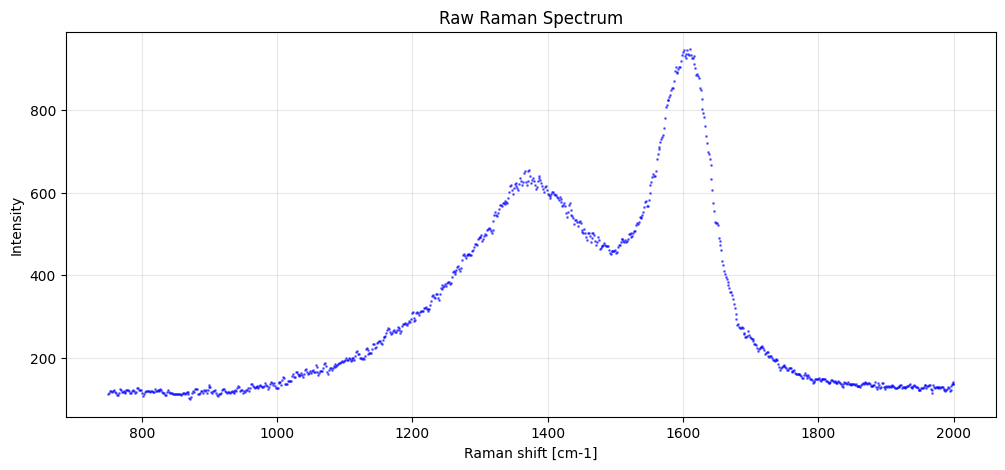

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(x, y, 'b.', alpha=0.5, markersize=2)
plt.xlabel('Raman shift [cm-1]')
plt.ylabel('Intensity')
plt.title('Raw Raman Spectrum')
plt.grid(True, alpha=0.3)
plt.show()

## 3. Setup 5-Component Model

Components:
- D (broad): Lorentzian, ~1350 cm⁻¹
- D1: Lorentzian, ~1377 cm⁻¹  
- D3: Gaussian, ~1555 cm⁻¹
- G: Lorentzian, ~1590 cm⁻¹
- D': Lorentzian, ~1622 cm⁻¹

In [14]:
# Background
bg = LinearModel(prefix='lin_')
pars = bg.guess(y, x=x)

# D PEAK CENTER - SAME position for both D and D1
d_center_fixed = 1360  # Both D peaks at same center

# 1. D (broad) - Lorentzian (broader width)
lorentz_d_broad = LorentzianModel(prefix='d_broad_')
pars.update(lorentz_d_broad.make_params())
pars['d_broad_center'].set(value=d_center_fixed, min=1350, max=1370)
pars['d_broad_sigma'].set(value=361/2, min=150, max=250)
pars['d_broad_amplitude'].set(value=50000, min=1000)

# 2. D1 - Lorentzian - SAME CENTER AS D_BROAD (narrower width)
lorentz_d1 = LorentzianModel(prefix='d1_')
pars.update(lorentz_d1.make_params())
pars['d1_center'].set(value=d_center_fixed, min=1350, max=1370)  # Same center as D_broad
pars['d1_sigma'].set(value=196/2, min=50, max=120)
pars['d1_amplitude'].set(value=30000, min=1000)

# 3. D3 - Gaussian (narrower, shifted higher)
gauss_d3 = GaussianModel(prefix='d3_')
pars.update(gauss_d3.make_params())
pars['d3_center'].set(value=1570, min=1540, max=1610)
pars['d3_sigma'].set(value=50/(2*np.sqrt(2*np.log(2))), min=15, max=80)
pars['d3_amplitude'].set(value=10000, min=100)

# 4. G - Lorentzian
lorentz_g = LorentzianModel(prefix='g_')
pars.update(lorentz_g.make_params())
pars['g_center'].set(value=1590, min=1560, max=1630)
pars['g_sigma'].set(value=79/2, min=20, max=80)
pars['g_amplitude'].set(value=50000, min=1000)

# 5. D' - Lorentzian (repositioned to 1520 cm-1)
lorentz_dp = LorentzianModel(prefix='dp_')
pars.update(lorentz_dp.make_params())
pars['dp_center'].set(value=1520, min=1510, max=1530)
pars['dp_sigma'].set(value=57/2, min=15, max=50)
pars['dp_amplitude'].set(value=30000, min=500)

print("Parameters initialized")
print("\n" + "="*70)
print("OPTIMIZED 5-PEAK MODEL SETUP (750-2000 cm-1 region)")
print("="*70)
print("✓ D (broad): center=1360±10, sigma=180.5 (BROADER)")
print("✓ D1: center=1360±10 (SAME as D), sigma=98 (NARROWER)")
print("✓ D3: center=1570, sigma=21.23 (Gaussian, narrow)")
print("✓ G: center=1590, sigma=39.5")
print("✓ D': center=1520, sigma=28.5 (repositioned from 1622)")
print("="*70)

Parameters initialized

OPTIMIZED 5-PEAK MODEL SETUP (750-2000 cm-1 region)
✓ D (broad): center=1360±10, sigma=180.5 (BROADER)
✓ D1: center=1360±10 (SAME as D), sigma=98 (NARROWER)
✓ D3: center=1570, sigma=21.23 (Gaussian, narrow)
✓ G: center=1590, sigma=39.5
✓ D': center=1520, sigma=28.5 (repositioned from 1622)


## 4. Perform Fitting

In [15]:
# Combine all models (5 components only, no 800cm feature)
mod = lorentz_d_broad + lorentz_d1 + gauss_d3 + lorentz_g + lorentz_dp + bg

# Fit
print("Fitting (5-component model, 750-2000 cm-1 region)...")
out = mod.fit(y, pars, x=x)
print("Fitting complete!")

print(out.fit_report())

Fitting (5-component model, 750-2000 cm-1 region)...
Fitting complete!
[[Model]]
    (((((Model(lorentzian, prefix='d_broad_') + Model(lorentzian, prefix='d1_')) + Model(gaussian, prefix='d3_')) + Model(lorentzian, prefix='g_')) + Model(lorentzian, prefix='dp_')) + Model(linear, prefix='lin_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 36000
    # data points      = 924
    # variables        = 17
    chi-square         = 78567.4253
    reduced chi-square = 86.6234016
    Akaike info crit   = 4139.33236
    Bayesian info crit = 4221.42046
    R-squared          = 0.99826038
##  Warning: uncertainties could not be estimated:
    d_broad_center:     at boundary
    d1_center:          at boundary
    dp_center:          at boundary
    dp_sigma:           at boundary
[[Variables]]
    lin_slope:          0.00946724 (init = 0.1064561)
    lin_intercept:      69.8445459 (init = 162.1826)
    d_broad_amplitude:  157388.101 (init = 50000)
    d_broad_center

## 5. Extract Fitted Parameters

In [16]:
vd = out.params.valuesdict()

# Display fitted parameters
print("\n" + "="*70)
print("FITTED PEAK PARAMETERS")
print("="*70)

peaks = [
    ('D (broad)', 'd_broad_'),
    ('D1', 'd1_'),
    ('D3', 'd3_'),
    ('G', 'g_'),
    ("D'", 'dp_')
]

for name, prefix in peaks:
    center = vd[f'{prefix}center']
    amplitude = vd[f'{prefix}amplitude']
    sigma = vd[f'{prefix}sigma']
    
    # Calculate FWHM
    if 'd3' in prefix:  # Gaussian
        fwhm = sigma * 2 * np.sqrt(2 * np.log(2))
    else:  # Lorentzian
        fwhm = sigma * 2
    
    center_err = out.params[f'{prefix}center'].stderr or 0
    
    print(f"\n{name}:")
    print(f"  Center:    {center:.2f} +/- {center_err:.2f} cm-1")
    print(f"  FWHM:      {fwhm:.2f} cm-1")
    print(f"  Amplitude: {amplitude:.2f}")

print(f"\nFit Quality:")
print(f"  R-squared: {1 - out.residual.var() / np.var(y):.6f}")
print(f"  Chi-square: {out.chisqr:.2f}")
print("="*70)


FITTED PEAK PARAMETERS

D (broad):
  Center:    1370.00 +/- 0.00 cm-1
  FWHM:      327.60 cm-1
  Amplitude: 157388.10

D1:
  Center:    1370.00 +/- 0.00 cm-1
  FWHM:      195.36 cm-1
  Amplitude: 67876.53

D3:
  Center:    1592.57 +/- 0.00 cm-1
  FWHM:      70.92 cm-1
  Amplitude: 31701.37

G:
  Center:    1624.08 +/- 0.00 cm-1
  FWHM:      69.17 cm-1
  Amplitude: 42249.95

D':
  Center:    1530.00 +/- 0.00 cm-1
  FWHM:      100.00 cm-1
  Amplitude: 18575.70

Fit Quality:
  R-squared: 0.998260
  Chi-square: 78567.43


## 6. Calculate Spectroscopic Ratios

In [17]:
# Extract intensities (heights for Lorentzian: amplitude * sigma * pi)
# For Gaussian: amplitude * sigma * sqrt(2*pi)

# Peak heights
h_d_broad = vd['d_broad_amplitude'] / vd['d_broad_sigma']
h_d1 = vd['d1_amplitude'] / vd['d1_sigma']
h_d3 = vd['d3_amplitude'] / vd['d3_sigma']
h_g = vd['g_amplitude'] / vd['g_sigma']
h_dp = vd['dp_amplitude'] / vd['dp_sigma']

# Peak areas (proportional to amplitude * fwhm for Lorentzian)
a_d_broad = np.pi * vd['d_broad_amplitude'] * vd['d_broad_sigma']
a_d1 = np.pi * vd['d1_amplitude'] * vd['d1_sigma']
a_d3 = np.pi * vd['d3_amplitude'] * vd['d3_sigma']
a_g = np.pi * vd['g_amplitude'] * vd['g_sigma']
a_dp = np.pi * vd['dp_amplitude'] * vd['dp_sigma']

# D1 + D (broad) combined
h_d_total = h_d_broad + h_d1
a_d_total = a_d_broad + a_d1

print("\n" + "="*70)
print("SPECTROSCOPIC RATIOS")
print("="*70)

print(f"\nIntensity Ratios (I = height):")
print(f"  I(D_broad)/I(G)  = {h_d_broad/h_g:.3f}")
print(f"  I(D1)/I(G)       = {h_d1/h_g:.3f}")
print(f"  I(D+D1)/I(G)     = {h_d_total/h_g:.3f}")
print(f"  I(D3)/I(G)       = {h_d3/h_g:.3f}")
print(f"  I(D')/I(G)       = {h_dp/h_g:.3f}")

print(f"\nArea Ratios (A = amplitude × FWHM):")
print(f"  A(D_broad)/A(G)  = {a_d_broad/a_g:.3f}")
print(f"  A(D1)/A(G)       = {a_d1/a_g:.3f}")
print(f"  A(D+D1)/A(G)     = {a_d_total/a_g:.3f}")
print(f"  A(D3)/A(G)       = {a_d3/a_g:.3f}")
print(f"  A(D')/A(G)       = {a_dp/a_g:.3f}")

print("="*70)


SPECTROSCOPIC RATIOS

Intensity Ratios (I = height):
  I(D_broad)/I(G)  = 0.786
  I(D1)/I(G)       = 0.569
  I(D+D1)/I(G)     = 1.355
  I(D3)/I(G)       = 0.862
  I(D')/I(G)       = 0.304

Area Ratios (A = amplitude × FWHM):
  A(D_broad)/A(G)  = 17.644
  A(D1)/A(G)       = 4.538
  A(D+D1)/A(G)     = 22.182
  A(D3)/A(G)       = 0.653
  A(D')/A(G)       = 0.636


## 7. Plot Results

Plot saved to: ramanfit_coaltar_result.png


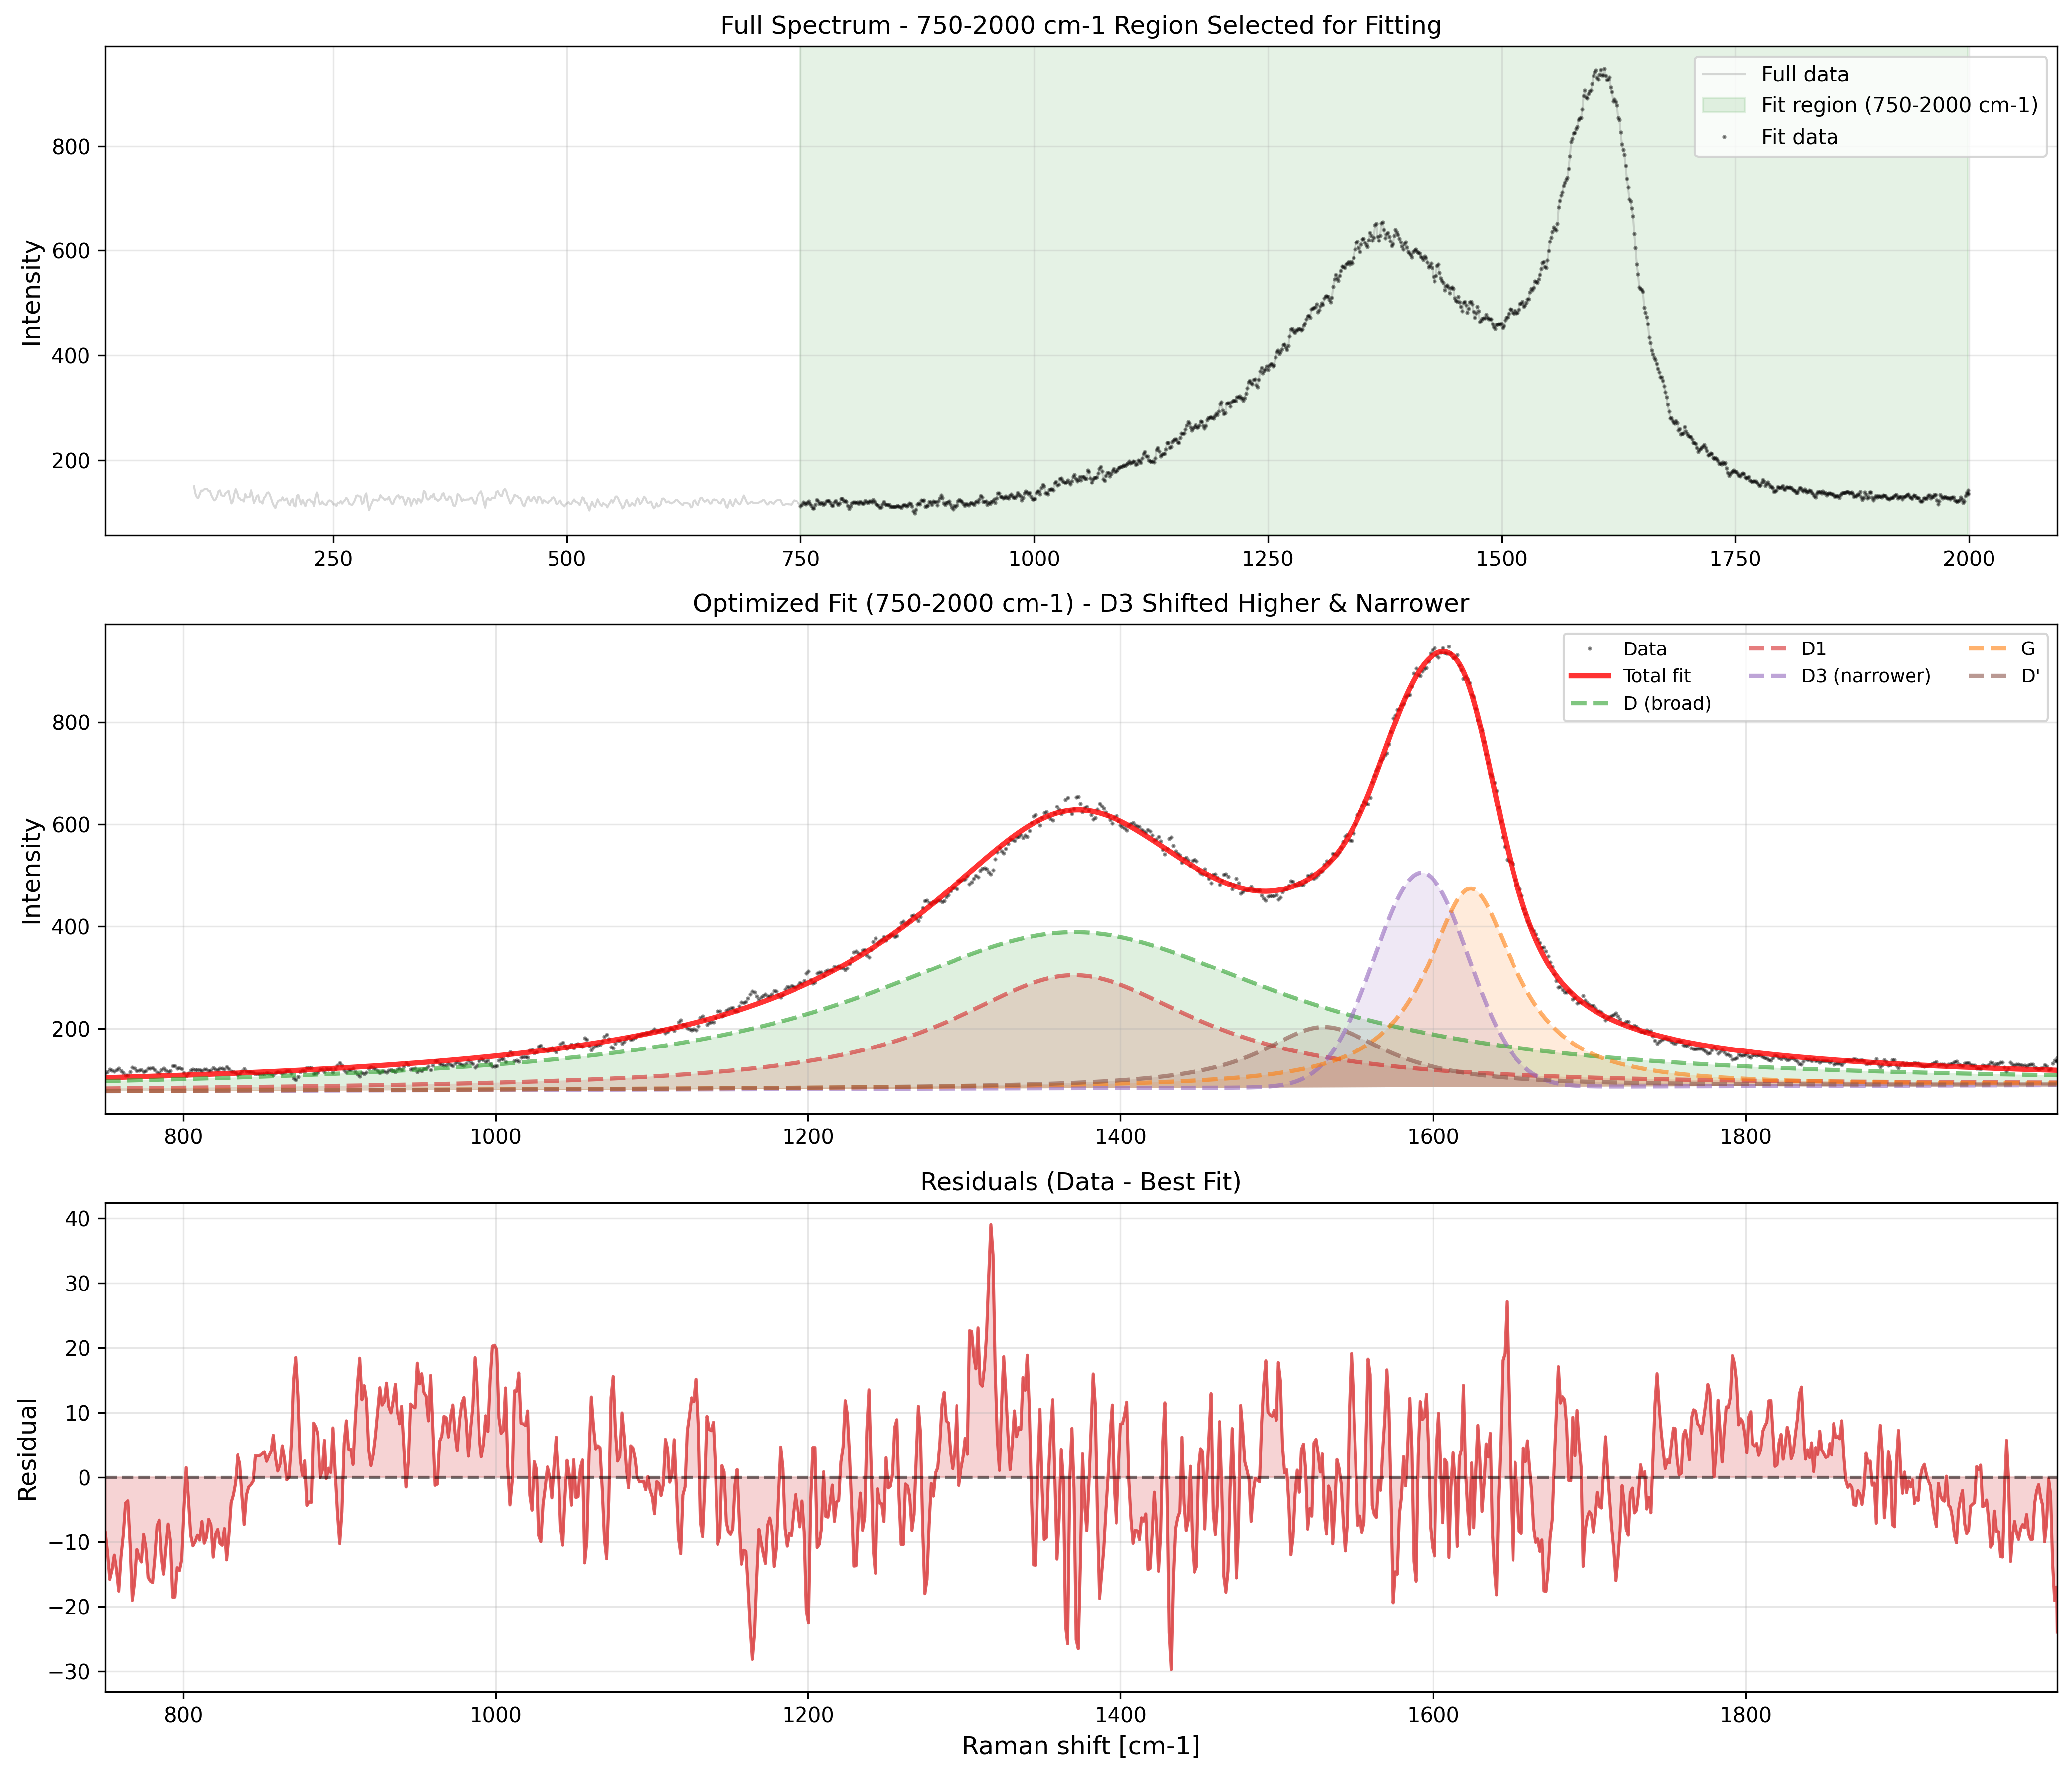

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(14, 12), dpi=300)

# Top: Full spectrum with fit region highlighted
ax[0].plot(x_full, y_full, 'gray', alpha=0.3, lw=1, label='Full data')
ax[0].axvspan(x[0], x[-1], alpha=0.1, color='green', label='Fit region (750-2000 cm-1)')
ax[0].plot(x, y, 'k.', alpha=0.4, markersize=2, label='Fit data')
ax[0].set_ylabel('Intensity', fontsize=12)
ax[0].legend(loc='upper right', fontsize=10)
ax[0].grid(True, alpha=0.3)
ax[0].set_title('Full Spectrum - 750-2000 cm-1 Region Selected for Fitting', fontsize=12)

# Middle: Fit region detail with components
ax[1].plot(x, y, 'k.', alpha=0.4, markersize=2, label='Data')
ax[1].plot(x, out.best_fit, 'r-', lw=2.5, alpha=0.8, label='Total fit')

# Plot individual components
comps = out.eval_components(x=x)
colors = ['C2', 'C3', 'C4', 'C1', 'C5']
component_names = [
    ('d_broad_', 'D (broad)'),
    ('d1_', 'D1'),
    ('d3_', 'D3 (narrower)'),
    ('g_', 'G'),
    ('dp_', "D'")
]

for color, (prefix, name) in zip(colors, component_names):
    if prefix in comps:
        component = comps[prefix] + comps['lin_']
        ax[1].plot(x, component, '--', color=color, label=name, lw=2, alpha=0.6)
        ax[1].fill_between(x, component, comps['lin_'], facecolor=color, alpha=0.15)

ax[1].set_ylabel('Intensity', fontsize=12)
ax[1].set_title('Optimized Fit (750-2000 cm-1) - D3 Shifted Higher & Narrower', fontsize=12)
ax[1].legend(loc='upper right', fontsize=9, ncol=3)
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(x[0], x[-1])

# Bottom: Residuals
residual = out.best_fit - y
ax[2].plot(x, residual, 'C3-', alpha=0.7, lw=1.5, label='Residual')
ax[2].axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax[2].fill_between(x, residual, 0, alpha=0.2, color='C3')
ax[2].set_xlabel('Raman shift [cm-1]', fontsize=12)
ax[2].set_ylabel('Residual', fontsize=12)
ax[2].set_title('Residuals (Data - Best Fit)', fontsize=12)
ax[2].grid(True, alpha=0.3)
ax[2].set_xlim(x[0], x[-1])

plt.tight_layout()
plt.savefig('ramanfit_coaltar_result.png', dpi=150, bbox_inches='tight')
print("Plot saved to: ramanfit_coaltar_result.png")
plt.show()

## 8. Summary Results

In [19]:
print("\n" + "#"*70)
print("# ANALYSIS SUMMARY")
print("#"*70)
print(f"\nFile: {INFILE}")
print(f"\nFit Quality: R² = {1 - out.residual.var() / np.var(y):.6f}")
print(f"\nKey Ratios:")
print(f"  I(D+D1)/I(G) = {h_d_total/h_g:.3f}")
print(f"  A(D1)/A(G)   = {a_d1/a_g:.3f}")
print(f"  I(D')/I(G)   = {h_dp/h_g:.3f}")
print("#"*70)


######################################################################
# ANALYSIS SUMMARY
######################################################################

File: /home/fur/src/ramanfit/data/l405.tsv

Fit Quality: R² = 0.998260

Key Ratios:
  I(D+D1)/I(G) = 1.355
  A(D1)/A(G)   = 4.538
  I(D')/I(G)   = 0.304
######################################################################
